In [1]:
import ROOT
import numpy as np
import matplotlib.pyplot as plt
import mplhep as hep
import matplotlib as mpl
import ipywidgets as widget
from XRootD import client
import os
import tqdm

Welcome to JupyROOT 6.30/04


In [2]:
year = widget.Dropdown( options = [ "2016APV", "2016", "2017", "2018" ], value = "2017" )
year

Dropdown(index=2, options=('2016APV', '2016', '2017', '2018'), value='2017')

In [8]:
lumitext = {
    "2016APV": "$19.52\ \mathrm{fb^{-1}}$",
    "2016": "$16.81\ \mathrm{fb^{-1}}$",
    "2017": "$41.48\ \mathrm{fb^{-1}}$",
    "2018": "$59.83\ \mathrm{fb^{-1}}$"
}

In [9]:
#bruxPrefix = "root://brux30.hep.brown.edu:1094/"
bruxPrefix = "root://cmseos.fnal.gov//"
fileDir = "/store/user/dali/FWLJMET106XUL_singleLep{}UL_RunIISummer20_3t_step3/nominal/".format( year.value )
xrdClient = client.FileSystem( bruxPrefix )
status, dirList = xrdClient.dirlist( fileDir )
samples = [ item.name for item in dirList ]

In [10]:
sampleNames = widget.SelectMultiple( options = sorted( samples ) )
sampleNames

SelectMultiple(options=('DYJetsToLL_M-50_HT-1200to2500_TuneCP5_PSweights_13TeV-madgraphMLM-pythia8_hadd.root',…

In [11]:
rFiles = {
    name: ROOT.TFile.Open( bruxPrefix + fileDir + name ) for name in sampleNames.value
}

In [12]:
rTrees = {
    name: rFiles[name].Get( "ljmet" ) for name in sampleNames.value
}

In [13]:
branches = [ branch.GetName() for branch in rTrees[ sampleNames.value[0] ].GetListOfBranches() ]
variable = widget.Dropdown( options = sorted( branches ) )
variable

Dropdown(options=('AK4HT', 'Aplanarity', 'BDTtrijet1', 'BDTtrijet2', 'BDTtrijet3', 'BDTtrijet4', 'BJetLeadPt',…

In [14]:
branches = [ branch.GetName() for branch in rTrees[ sampleNames.value[0] ].GetListOfBranches() ]
variable2 = widget.Dropdown( options = sorted( branches ) )
variable2

Dropdown(options=('AK4HT', 'Aplanarity', 'BDTtrijet1', 'BDTtrijet2', 'BDTtrijet3', 'BDTtrijet4', 'BJetLeadPt',…

In [15]:
values = { "ALL": { variable.value: [], variable2.value: [] } }
for name in rTrees:
    print( "[INFO] Processing {}".format( name ) )
    values[name] = { variable.value: [], variable2.value: [] }
    for i in tqdm.tqdm( range( int( rTrees[name].GetEntries() / 20 ) ) ):
        nB = rTrees[name].GetEntry(i)
        if getattr( rTrees[name], "AK4HT" ) < 500: continue
        if getattr( rTrees[name], "NJetsCSV_JetSubCalc" ) < 1: continue
        if getattr( rTrees[name], "NJets_JetSubCalc" ) < 3: continue
        if getattr( rTrees[name], "DataPastTriggerX" ) != 1: continue
        if getattr( rTrees[name], "MCPastTriggerX" ) != 1: continue
        if getattr( rTrees[name], "minDR_lepJet" ) < 0.2: continue
        value = getattr( rTrees[name], variable.value )
        value2 = getattr( rTrees[name], variable2.value )
        if type( value ) is not int and type( value ) is not float:
            for val_ in value:
                values[name][ variable.value ].append( val_ )
                values["ALL"][ variable.value ].append( val_ )
        else:
            values[name][ variable.value ].append( value )
            values["ALL"][ variable.value ].append( value )
        if type( value2 ) is not int and type( value2 ) is not float:
            for val_ in value2:
                values[name][ variable2.value ].append( val_ )
                values["ALL"][ variable2.value ].append( val_ )
        else:
            values[name][ variable2.value ].append( value2 )
            values["ALL"][ variable2.value ].append( value2 )

[INFO] Processing TTTJ_TuneCP5_13TeV-madgraph-pythia8_hadd.root


100%|██████████| 4144/4144 [00:02<00:00, 1931.47it/s]


In [16]:
plotNames = widget.SelectMultiple( options = sorted( values.keys() ) )
plotNames

SelectMultiple(options=('ALL', 'TTTJ_TuneCP5_13TeV-madgraph-pythia8_hadd.root'), value=())

In [17]:
plotValues = {}
for name in plotNames.value:
    plotValues[ name ] = { variable.value: [], variable2.value: [] }
    for key in values[ name ]:
        for i in range( len( values[ name ][ key ] ) ):
            plotValues[ name ][key].append( values[ name ][key][i] )

In [18]:
plotVar = widget.Dropdown( options = [ variable.value, variable2.value ] )
plotVar

Dropdown(options=('pdfWeights', 'renormWeights'), value='pdfWeights')

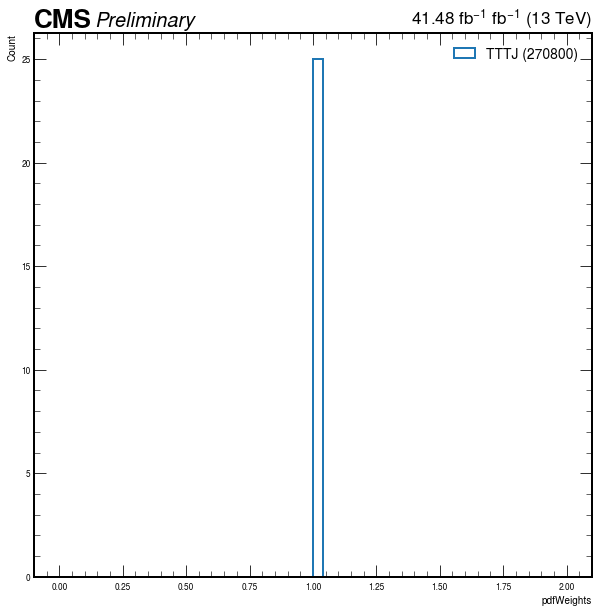

In [19]:
bins = np.linspace( 0, 2, 51 )
hists = []
labels = []
for name in plotNames.value:
    hists.append( plotValues[ name ][plotVar.value] )
    labels.append( "{} ({})".format( name.split( "_hadd" )[0].split( "_TuneCP5" )[0], len( values[ name ][ plotVar.value ] ) ) )
plt.style.use( hep.style.CMS )
plt.figure( figsize = (10,10) )
hep.cms.text( "Preliminary", fontsize = 20 )
hep.cms.lumitext( lumitext[ year.value ] + " $fb^{-1}$ (13 TeV)", fontsize = 18 )
for name in plotNames.value:
    plt.hist( plotValues[ name ][plotVar.value], bins = bins, histtype = "step", lw = 2, density = True, label = "{} ({})".format( name.split( "_hadd" )[0].split( "_TuneCP5" )[0], len( values[ name ][ plotVar.value ] ) ) )
#if len( hists ) > 1:
#    plt.hist( np.array( hists, dtype = object ), bins = bins, stacked = True, label = labels )
#else:
#    plt.hist( hists[0], bins = bins, label = labels[0] )

#plt.yscale( "log" )
plt.ylabel( "Count", y = 1.0, ha = "right" )
plt.xlabel( plotVar.value, x = 1.0, ha = "right" )
plt.legend( loc = "best", fontsize = 14 )
plt.show()
plt.close()
del hists, labels

## Plot correlation between two variables

In [18]:
plotName = widget.Dropdown( options = sorted( values.keys() ) )
plotName

Dropdown(options=('ALL', 'TTTJ_TuneCP5_13TeV-madgraph-pythia8_hadd.root', 'TTTT_TuneCP5_13TeV-amcatnlo-pythia8…

In [24]:
plotValue = { variable.value: [], variable2.value: [] }
for key in values[ plotName.value ]:
    for i in range( len( values[ plotName.value ][ key ] ) ):
        if type( values[ plotName.value ][key][i] ) != float and type( values[ plotName.value ][key][i] ) != int:
            plotValue[key].append( values[ plotName.value ][key][i].at(3) )
        else:
            plotValue[key].append( values[ plotName.value ][key][i] )

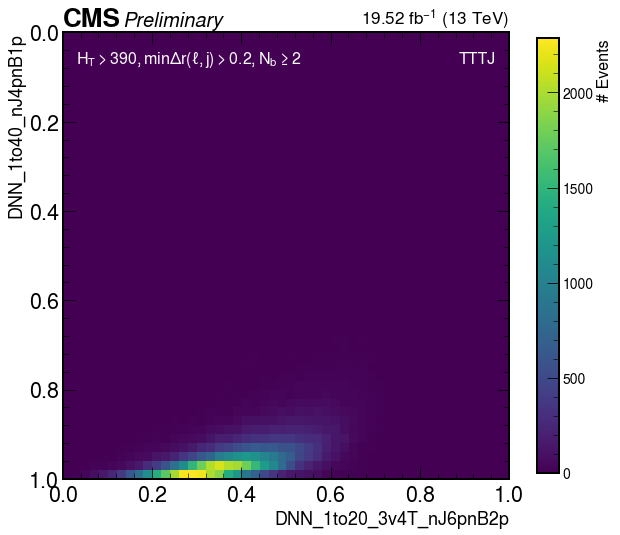

In [38]:
bins1 = np.linspace( 0, 1., 51 )
bins2 = np.linspace( 0, 1., 51 )
hist2D = np.histogram2d( plotValue[variable.value], plotValue[variable2.value], bins = [ bins1, bins2 ] )

plt.style.use( hep.style.CMS )
plt.figure()
hep.cms.text( "Preliminary", fontsize = 20 )
hep.cms.lumitext( lumitext[ year.value ] + " (13 TeV)", fontsize = 18 )

plt.imshow( hist2D[0] )
cbar = plt.colorbar( shrink = 0.8 )
cbar.ax.set_ylabel( "# Events", fontsize = 16 )
cbar.ax.tick_params( labelsize = 14 )
plt.xlabel( variable2.value, fontsize = 18 )
plt.yticks( np.linspace( -0.5, -1.5 + len( hist2D[1] ), len( hist2D[1][::10] ) ), labels = [ float(i) for i in hist2D[1][::10] ] )
plt.ylabel( variable.value, fontsize = 18 )
plt.xticks( np.linspace( -0.5, -1.5 + len( hist2D[2] ), len( hist2D[2][::10] ) ), labels = [ float(i) for i in hist2D[2][::10] ] )
        
plt.annotate( "TTTJ", ( 0.97, 0.94 ), xycoords = "axes fraction", ha = "right", va = "center", fontsize = 16, color = "white" )
plt.annotate( r"$H_T>390,min\Delta r(\ell,j)>0.2,N_b\geq 2$", ( 0.03, 0.94 ), xycoords = "axes fraction", ha = "left", va = "center", fontsize = 16, color = "white" )
    
plt.show()
plt.close()

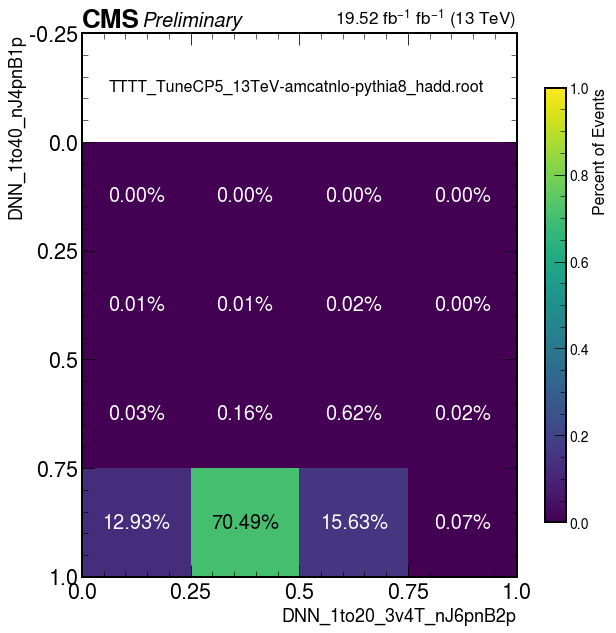

In [31]:
bins1 = np.linspace( 0, 1, 5 )
bins2 = np.linspace( 0, 1, 5 )
hist2D = np.histogram2d( plotValue[variable.value], plotValue[variable2.value], bins = [ bins1, bins2 ] )

plt.style.use( hep.style.CMS )
plt.figure()
hep.cms.text( "Preliminary", fontsize = 20 )
hep.cms.lumitext( lumitext[ year.value ] + " $fb^{-1}$ (13 TeV)", fontsize = 18 )

plt.imshow( hist2D[0] / np.sum( hist2D[0] ), vmin = 0, vmax = 1. )
cbar = plt.colorbar( shrink = 0.8 )
cbar.ax.set_ylabel( "Percent of Events", fontsize = 16 )
cbar.ax.tick_params( labelsize = 14 )
plt.xlabel( variable2.value, fontsize = 18 )
plt.yticks( np.linspace( -1.5, -1.5 + len( hist2D[1] ), len( hist2D[1] ) + 1 ), labels = [ float( 2*hist2D[1][0] - hist2D[1][1] ) ] + [ float(i) for i in hist2D[1] ] )
plt.ylabel( variable.value, fontsize = 18 )
plt.xticks( np.linspace( -0.5, -1.5 + len( hist2D[2] ), len( hist2D[2] ) ), labels = [ float(i) for i in hist2D[2] ] )

for i in range( len( hist2D[1] ) - 1 ):
    for j in range( len( hist2D[2] ) - 1 ):
        color = "white" if ( hist2D[0][i][j] / np.sum( hist2D[0] ) ) < 0.5 else "black"
        plt.annotate( "{:.2f}%".format( 100. * hist2D[0][i][j] / np.sum( hist2D[0] ) ), ( j, i ), ha = "center", va = "center", c = color, fontsize = 20 )

plt.annotate( plotName.value, ( -0.25, -1 ), ha = "left", va = "center", fontsize = 16 )
        
plt.show()
plt.close()

In [28]:
group1 = widget.SelectMultiple( options = sorted( values.keys() )  )
group1

SelectMultiple(options=('ALL', 'TTTJ_TuneCP5_13TeV-madgraph-pythia8_hadd.root', 'TTTT_TuneCP5_13TeV-amcatnlo-p…

In [29]:
group2 = widget.SelectMultiple( options = sorted( values.keys() )  )
group2

SelectMultiple(options=('ALL', 'TTTJ_TuneCP5_13TeV-madgraph-pythia8_hadd.root', 'TTTT_TuneCP5_13TeV-amcatnlo-p…

In [32]:
scatters1 = { variable.value: [], variable2.value: [] }
scatters2 = { variable.value: [], variable2.value: [] }

for group in group1.value:
    for key in values[ group ]:
        for i in range( len( values[ group ][ key ] ) ):
            if type( values[group][key][i] ) != float and type( values[group][key][i] ) != int:
                scatters1[key].append( values[ group ][key][i].at(3) )
            else:
                scatters1[key].append( values[group][key][i] )
for group in group2.value:
    for key in values[ group ]:
        for i in range( len( values[ group ][ key ] ) ):
            if type( values[group][key][i] ) != float and type( values[group][key][i] ) != int:
                scatters2[key].append( values[ group ][key][i].at(3) )
            else:
                scatters2[key].append( values[group][key][i] )

/tmp/ipykernel_2201/2009267952.py:5: RuntimeWarning: divide by zero encountered in true_divide
  hist2D = hist2D1[0] / hist2D2[0]
/tmp/ipykernel_2201/2009267952.py:5: RuntimeWarning: invalid value encountered in true_divide
  hist2D = hist2D1[0] / hist2D2[0]


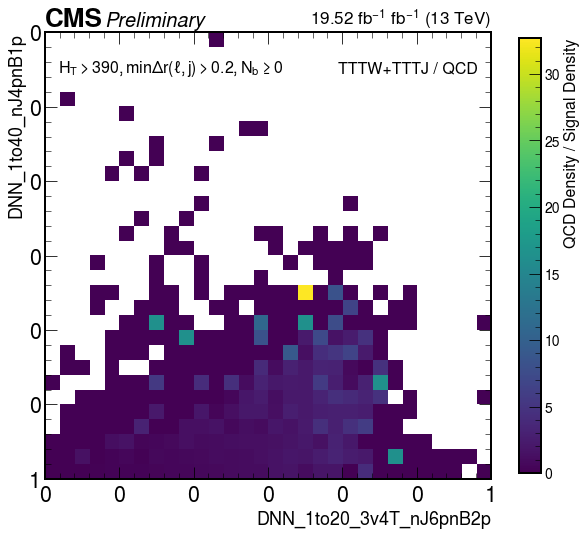

In [33]:
bins1 = np.linspace( 0, 1, 31 )
bins2 = np.linspace( 0, 1, 31 )
hist2D1 = np.histogram2d( scatters1[variable.value], scatters1[variable2.value], bins = [ bins1, bins2 ], density = True )
hist2D2 = np.histogram2d( scatters2[variable.value], scatters2[variable2.value], bins = [ bins1, bins2 ], density = True )
hist2D = hist2D1[0] / hist2D2[0]

plt.style.use( hep.style.CMS )
plt.figure()
hep.cms.text( "Preliminary", fontsize = 20 )
hep.cms.lumitext( lumitext[ year.value ] + " $fb^{-1}$ (13 TeV)", fontsize = 18 )

plt.imshow( hist2D )
cbar = plt.colorbar( shrink = 0.8 )
cbar.ax.set_ylabel( "QCD Density / Signal Density", fontsize = 16 )
cbar.ax.tick_params( labelsize = 14 )
plt.xlabel( variable2.value, fontsize = 18 )
plt.yticks( np.linspace( -0.5, -1.5 + len( hist2D1[1] ), len( hist2D1[1][::5] ) ), labels = [ int(i) for i in hist2D1[1][::5] ] )
plt.ylabel( variable.value, fontsize = 18 )
plt.xticks( np.linspace( -0.5, -1.5 + len( hist2D1[2] ), len( hist2D1[2][::5] ) ), labels = [ int(i) for i in hist2D1[2][::5] ] )
        
plt.annotate( "TTTW+TTTJ / QCD", ( 0.97, 0.92 ), xycoords = "axes fraction", ha = "right", va = "center", fontsize = 16, color = "black" )
plt.annotate( r"$H_T>390,min\Delta r(\ell,j)>0.2,N_b\geq 0$", ( 0.03, 0.92 ), xycoords = "axes fraction", ha = "left", va = "center", fontsize = 16, color = "black" )
    
plt.show()
plt.close()